# Graph Inspection and Visualization

This notebook loads and visualizes the graphs from the fine grid generation process.

In [2]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

## Load all graphs from directory

In [3]:
# Define the directory
graphs_dir = Path("/home/fbellisardi/code/topolity/data/data_processed/barcelone/graphs_fine_grid")

# Load all pickle files
graphs = {}
for pkl_file in sorted(graphs_dir.glob("graph_*.pkl")):
    graph_name = pkl_file.stem.replace("graph_", "")
    with open(pkl_file, 'rb') as f:
        graphs[graph_name] = pickle.load(f)
    print(f"Loaded {graph_name}: {len(graphs[graph_name].nodes())} nodes, {len(graphs[graph_name].edges())} edges")

print(f"\nTotal graphs loaded: {len(graphs)}")

Loaded original: 18329 nodes, 51509 edges
Loaded trans_100m_a+255: 18329 nodes, 51509 edges
Loaded trans_100m_a+255: 18329 nodes, 51509 edges
Loaded trans_150m_a+255: 18329 nodes, 51509 edges
Loaded trans_150m_a+255: 18329 nodes, 51509 edges
Loaded trans_50m_a+255: 18329 nodes, 51509 edges

Total graphs loaded: 4
Loaded trans_50m_a+255: 18329 nodes, 51509 edges

Total graphs loaded: 4


## Inspect fine grid statistics

In [4]:
# Load and display statistics
stats_file = graphs_dir / "fine_grid_stats.csv"
if stats_file.exists():
    stats = pd.read_csv(stats_file)
    display(stats)
else:
    print("No statistics file found")

,variant,type,offset_x,offset_y,angle_deg,translation_angle,translation_distance_m,num_nodes,num_edges,z_mean,z_min,z_max,edge_len_mean,missing_altitude,on_land
0,original,original,0.000000,0.000000,0.0,0.0,0,18329,51509,111.168804,-3.0,500.0,332.444609,0,True
1,trans_50m_a+255,translate,-0.000155,-0.000435,0.0,255.0,50,18329,51509,110.463910,-3.0,494.0,332.444609,0,True
2,trans_100m_a+255,translate,-0.000311,-0.000870,0.0,255.0,100,18329,51509,109.756561,-3.0,506.0,332.444609,0,True
3,trans_150m_a+255,translate,-0.000466,-0.001305,0.0,255.0,150,18329,51509,109.015113,-3.0,506.0,332.444609,0,True


## Plot all graphs with different colors

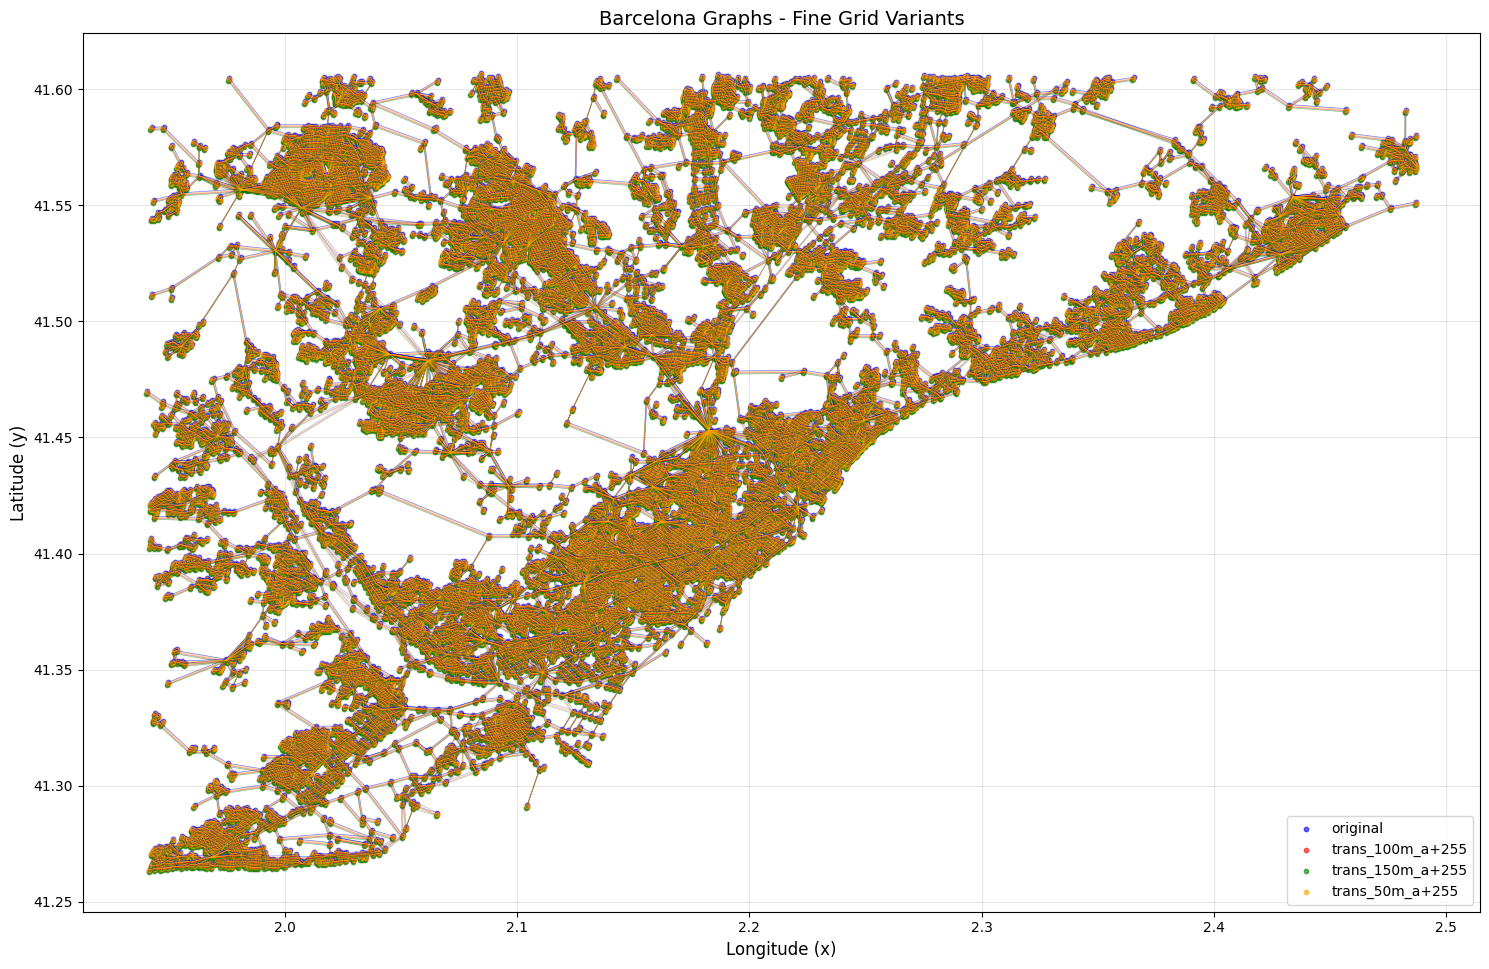

In [5]:
# Define colors for each graph
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Create figure
fig, ax = plt.subplots(figsize=(15, 15))

# Plot each graph with a different color
for idx, (name, G) in enumerate(graphs.items()):
    color = colors[idx % len(colors)]
    
    # Extract node coordinates
    x = [data['x'] for node, data in G.nodes(data=True)]
    y = [data['y'] for node, data in G.nodes(data=True)]
    
    # Plot nodes
    ax.scatter(x, y, c=color, s=10, alpha=0.6, label=name)
    
    # Plot edges
    for u, v in G.edges():
        x_coords = [G.nodes[u]['x'], G.nodes[v]['x']]
        y_coords = [G.nodes[u]['y'], G.nodes[v]['y']]
        ax.plot(x_coords, y_coords, c=color, alpha=0.3, linewidth=0.5)

ax.set_xlabel('Longitude (x)', fontsize=12)
ax.set_ylabel('Latitude (y)', fontsize=12)
ax.set_title('Barcelona Graphs - Fine Grid Variants', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Plot individual graphs in separate subplots

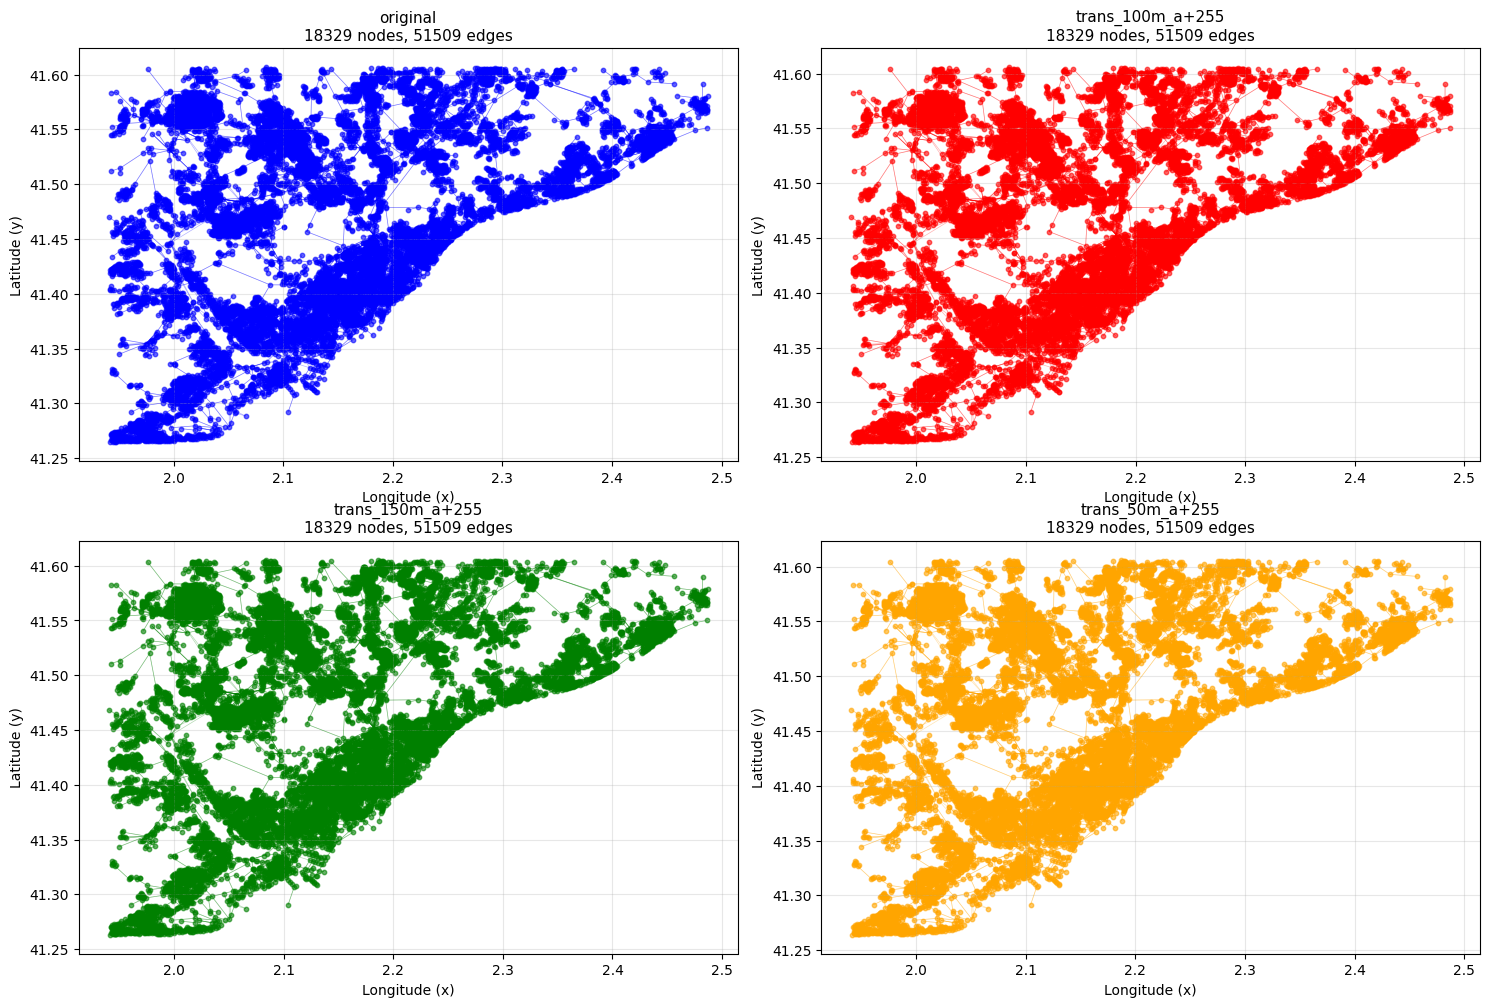

In [6]:
# Create subplots for individual graphs
n_graphs = len(graphs)
n_cols = 2
n_rows = (n_graphs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_graphs > 1 else [axes]

for idx, (name, G) in enumerate(graphs.items()):
    ax = axes[idx]
    color = colors[idx % len(colors)]
    
    # Extract node coordinates
    x = [data['x'] for node, data in G.nodes(data=True)]
    y = [data['y'] for node, data in G.nodes(data=True)]
    
    # Plot nodes
    ax.scatter(x, y, c=color, s=10, alpha=0.6)
    
    # Plot edges
    for u, v in G.edges():
        x_coords = [G.nodes[u]['x'], G.nodes[v]['x']]
        y_coords = [G.nodes[u]['y'], G.nodes[v]['y']]
        ax.plot(x_coords, y_coords, c=color, alpha=0.3, linewidth=0.5)
    
    ax.set_xlabel('Longitude (x)', fontsize=10)
    ax.set_ylabel('Latitude (y)', fontsize=10)
    ax.set_title(f'{name}\n{len(G.nodes())} nodes, {len(G.edges())} edges', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# Hide unused subplots
for idx in range(n_graphs, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Compare graph statistics

In [7]:
# Create a comparison dataframe
comparison_data = []
for name, G in graphs.items():
    x_coords = [data['x'] for node, data in G.nodes(data=True)]
    y_coords = [data['y'] for node, data in G.nodes(data=True)]
    
    comparison_data.append({
        'Graph': name,
        'Nodes': len(G.nodes()),
        'Edges': len(G.edges()),
        'X_min': min(x_coords),
        'X_max': max(x_coords),
        'Y_min': min(y_coords),
        'Y_max': max(y_coords),
        'X_range': max(x_coords) - min(x_coords),
        'Y_range': max(y_coords) - min(y_coords)
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Graph,Nodes,Edges,X_min,X_max,Y_min,Y_max,X_range,Y_range
0,original,18329,51509,1.940913,2.487272,41.264279,41.606791,0.546359,0.342513
1,trans_100m_a+255,18329,51509,1.940602,2.486961,41.263408,41.605921,0.546359,0.342513
2,trans_150m_a+255,18329,51509,1.940447,2.486806,41.262973,41.605486,0.546359,0.342513
3,trans_50m_a+255,18329,51509,1.940758,2.487117,41.263843,41.606356,0.546359,0.342513
